In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA



In [2]:
import os 
cwd = os.getcwd()

# Load the dataset
# Make sure your CSV file is in the same directory as the script
df = pd.read_csv(os.path.join(cwd, 'c1c3000_features_extended.csv'), index_col= 'unique_id')
# Prepare the data for analysis
# Drop the 'label' column as it's an identifier, not a feature
features = df.drop('label', axis=1)


In [3]:
# Scale the features, which is crucial for clustering algorithms
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("Data scaled and prepared for clustering.")


Data scaled and prepared for clustering.


In [4]:

# --- 2. Find Optimal Number of Clusters with BIC ---
print("\n--- Finding optimal number of clusters using BIC ---")
# Define the range of clusters to test
n_components_range = range(2, 11) 
bic_scores = []

for n_components in n_components_range:
    # Fit a Gaussian Mixture Model for each number of components
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(features_scaled)
    # Store the BIC score
    bic_scores.append(gmm.bic(features_scaled))


--- Finding optimal number of clusters using BIC ---


The optimal number of clusters is: 5


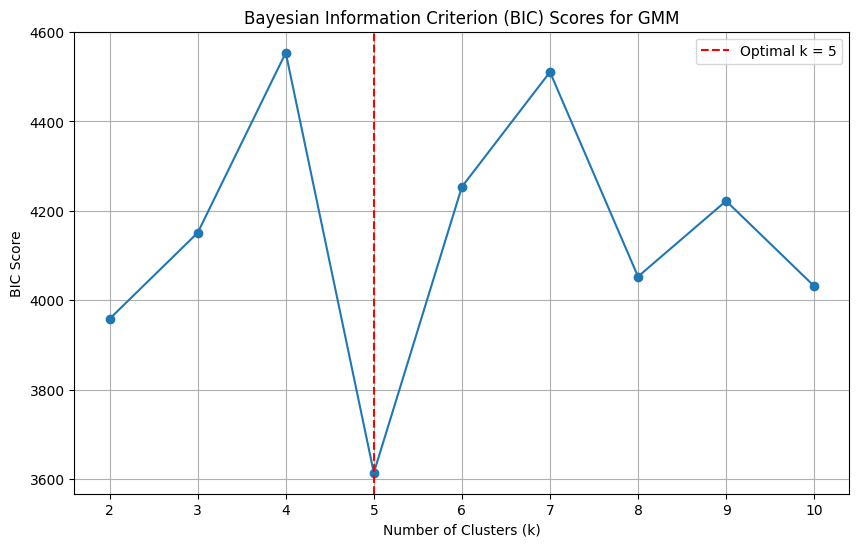

In [5]:

# Find the number of clusters that resulted in the minimum BIC score
optimal_n_clusters = n_components_range[np.argmin(bic_scores)]
print(f"The optimal number of clusters is: {optimal_n_clusters}")

# Plot the BIC scores for visual inspection
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o')
plt.axvline(x=optimal_n_clusters, color='r', linestyle='--', label=f'Optimal k = {optimal_n_clusters}')
plt.title('Bayesian Information Criterion (BIC) Scores for GMM')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC Score')
plt.legend()
plt.grid(True)
# plt.savefig('bic_scores_plot.png')
# plt.close()


In [6]:

# --- 3. Apply K-Means and Spectral Clustering ---
print(f"\n--- Applying clustering algorithms with k={optimal_n_clusters} ---")

# K-Means Clustering
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(features_scaled)
df['kmeans_cluster'] = kmeans_labels
print("Applied K-Means clustering.")



--- Applying clustering algorithms with k=5 ---
Applied K-Means clustering.


In [7]:
#  Spectral Clustering with a Gaussian (RBF) kernel
spectral = SpectralClustering(n_clusters=optimal_n_clusters, affinity='rbf', random_state=42)
spectral_labels = spectral.fit_predict(features_scaled)
df['spectral_cluster'] = spectral_labels
print("Applied Spectral Clustering.")


Applied Spectral Clustering.


In [8]:
# save the df with the cluster labels
df.to_csv('c1c3000_features_extended_with_clusters.csv')
print("Saved the dataset with cluster labels to 'c1c3000_features_extended_with_clusters.csv'.")

Saved the dataset with cluster labels to 'c1c3000_features_extended_with_clusters.csv'.


In [9]:
# visualize the clustering results using PCA
# --- 4. Visualize the Clusters using PCA ---
print("\n--- Visualizing clusters ---")
# Reduce data to 2 dimensions for plotting
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features_scaled)
pc_df = pd.DataFrame(data=principal_components, columns=['PC 1', 'PC 2'], index=df.index)
pc_df['kmeans_cluster'] = df['kmeans_cluster']
pc_df['spectral_cluster'] = df['spectral_cluster']



--- Visualizing clusters ---


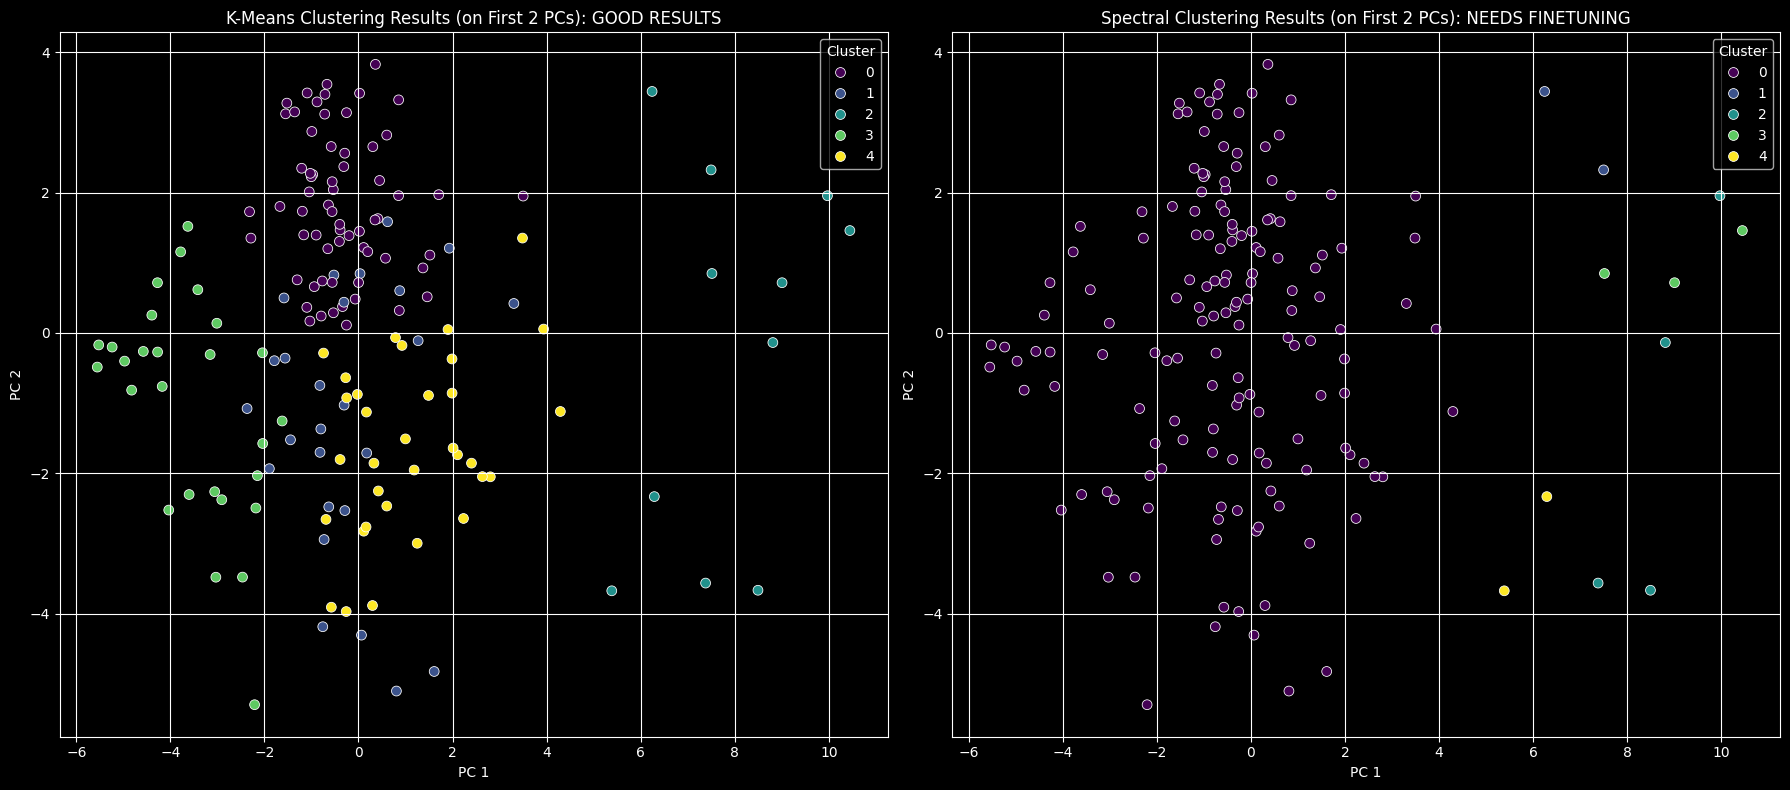

In [45]:

# Create subplots for each clustering method
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# K-Means Plot
sns.scatterplot(x='PC 1', y='PC 2', hue='kmeans_cluster', data=pc_df, palette='viridis', s=50, ax=axes[0])
axes[0].set_title('K-Means Clustering Results (on First 2 PCs): GOOD RESULTS')
axes[0].legend(title='Cluster')
axes[0].grid(True)

# Spectral Clustering Plot
sns.scatterplot(x='PC 1', y='PC 2', hue='spectral_cluster', data=pc_df, palette='viridis', s=50, ax=axes[1])
axes[1].set_title('Spectral Clustering Results (on First 2 PCs): NEEDS FINETUNING')
axes[1].legend(title='Cluster')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('extended_features_clustering_results_plot.png')
# plt.close()
# print("Saved cluster visualization plot as 'clustering_results_plot.png'")








Text(0, 0.5, 'Number of Cells in this cluster')

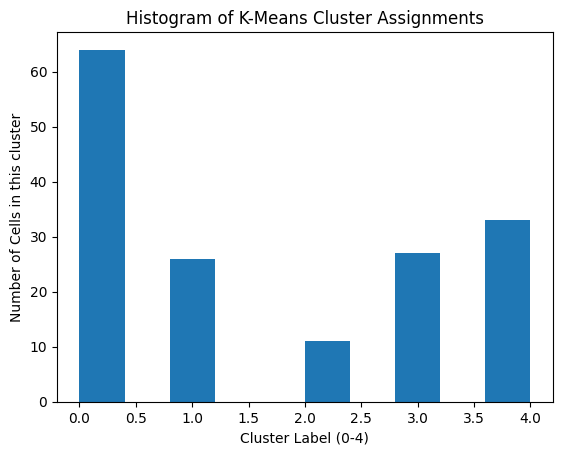

In [ ]:
kmeans_labels = df['kmeans_cluster']

plt.plot()
plt.hist(kmeans_labels)
plt.title('Histogram of K-Means Cluster Assignments')
plt.xlabel('Cluster Label (0-4)')run
plt.ylabel('Number of Cells in this cluster')

In [21]:
# plot representation of the clusters
from skimage import measure, io, color

import os

im_path = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data"
file_name= os.listdir(im_path)
# print(file_name)  

# load the seg data
mask_path = os.path.join(im_path, 'C1-C30000_seg.npy')
seg_data = np.load(mask_path, allow_pickle=True).item()
# The labeled mask where each nucleus has a unique integer ID
labeled_mask = seg_data['masks'] 



# load the image
image_path = os.path.join(im_path, 'C1-C30000.png')
# Load the image (convert to grayscale if it's RGB)
image = io.imread(image_path)
if image.ndim == 3:
    image = color.rgb2gray(image)
# Ensure image is in a standard format (e.g., 8-bit or 16-bit unsigned integer)
image = (image / np.max(image) * 255).astype(np.uint8)


# verify shapes 
print(labeled_mask.shape, image.shape)


df.head()

(1024, 1024) (1024, 1024)


,label,area,perimeter,solidity,extent,mean_intensity,max_intensity,min_intensity,eccentricity,major_axis_length,...,glcm_homogeneity,glcm_energy,glcm_correlation,cell_height_y,mean_dist_to_5_neighbors,n_chromocenters,mean_chromocenter_area,chromocenter_area_fraction,kmeans_cluster,spectral_cluster
unique_id,,,,,,,,,,,,,,,,,,,,,
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_1,1,762.0,105.941125,0.963338,0.814103,119.308399,255.0,12.0,0.706185,37.446909,...,0.041787,0.028273,0.806814,11.828084,67.536428,6,53.666667,0.422572,3,0
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_2,2,1191.0,126.083261,0.981054,0.847084,106.036944,255.0,9.0,0.254669,39.663566,...,0.039730,0.023207,0.774130,18.047019,59.976544,16,28.750000,0.386230,3,0
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_3,3,1177.0,128.325902,0.974338,0.797425,88.415463,206.0,8.0,0.579887,43.033066,...,0.043736,0.024427,0.604410,19.292268,60.765543,10,55.700000,0.473237,3,0
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_4,4,697.0,103.840620,0.969402,0.757609,145.647059,255.0,18.0,0.822307,40.011962,...,0.047559,0.030873,0.769421,9.868006,71.669982,11,28.272727,0.446198,3,0
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_5,5,395.0,80.526912,0.940476,0.707885,73.962025,167.0,9.0,0.772653,29.112273,...,0.069568,0.041007,0.571550,7.769620,53.337739,8,21.000000,0.425316,3,0


In [ ]:
def plot_cluster_representatives(features_df=df, segmentation_mask=labeled_mask):
    """
    Loads cell features and segmentation data to plot representative
    cell outlines for each k-means cluster.
    """

    # --- 2. Prepare for Plotting ---
    cluster_col = 'kmeans_cluster' # only interested in kmeans rn 
    unique_clusters = sorted(features_df[cluster_col].unique())
    n_clusters = len(unique_clusters)
    n_representatives = 6

    fig, axes = plt.subplots(n_clusters, n_representatives, figsize=(15, 15))
    fig.suptitle('Representative Cell Segmentations per K-Means Clusters', fontsize=20, y=0.95)

    # --- 3. Iterate, Find Contours, and Plot ---
    for i, cluster_id in enumerate(unique_clusters):
        # Get cells for the current cluster
        cluster_cells = features_df[features_df[cluster_col] == cluster_id]
        
        # Randomly sample 5 cells. If fewer than 5, take all.
        n_samples = min(n_representatives, len(cluster_cells))
        representative_samples = cluster_cells.sample(n=n_samples, random_state=42)

        axes[i, 0].set_ylabel(f'Cluster {cluster_id}', fontsize=14, rotation=90, labelpad=20)

        for j, (_, cell_row) in enumerate(representative_samples.iterrows()):
            cell_label = int(cell_row['label'])
            ax = axes[i, j]

            # Create a binary mask for the specific cell
            cell_mask = (segmentation_mask == cell_label)

            # Find contours of the cell
            contours = measure.find_contours(cell_mask, 0.5)
            
            # Plot the largest contour
            if contours:
                largest_contour = max(contours, key=len)
                ax.plot(largest_contour[:, 1], largest_contour[:, 0], linewidth=2)
            ax.set_aspect('equal', adjustable='box')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Cell ID: {cell_label}")
            ax.invert_yaxis() # Match image coordinate system

    for j in range(n_representatives):
        axes[0, j].set_title(f"Representative {j+1}\n(Cell ID: {representative_samples.iloc[j]['label']})")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()



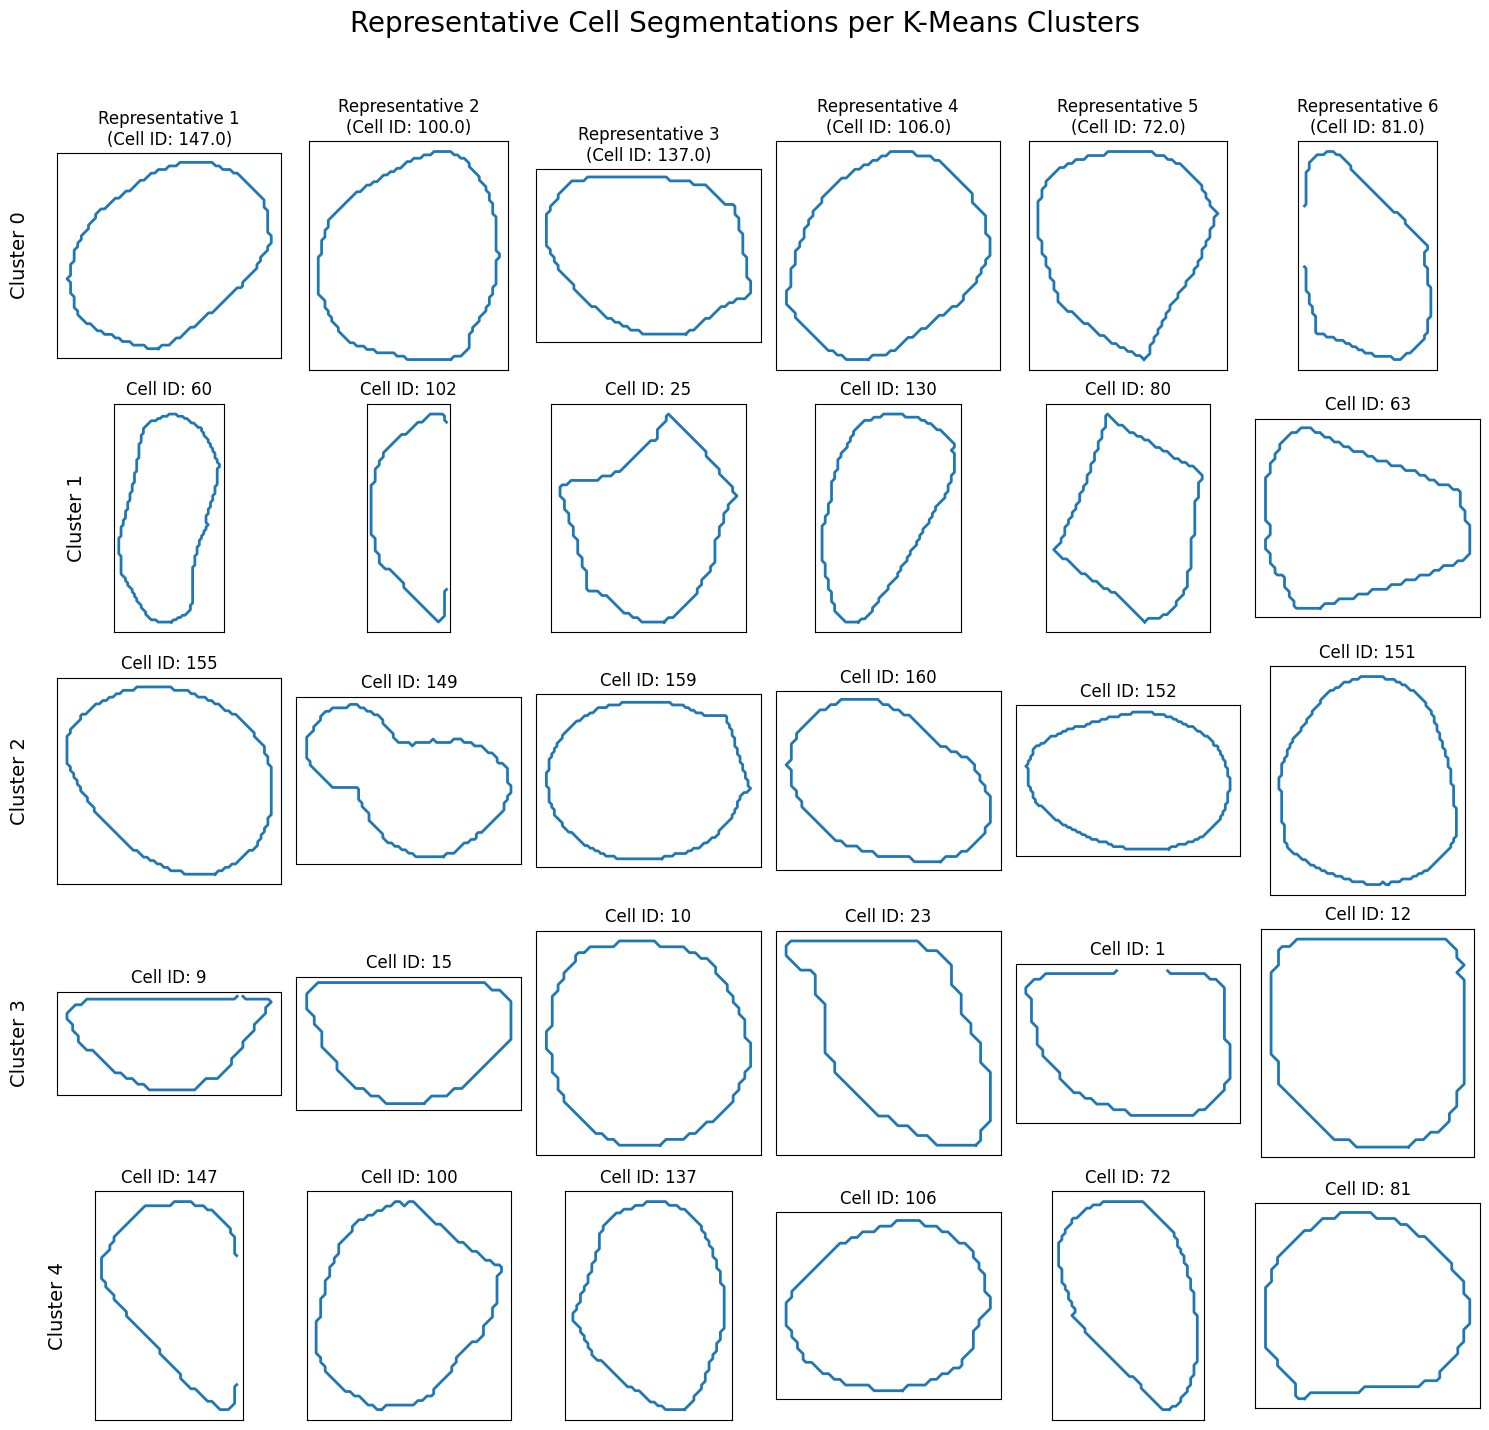

In [18]:
plot_cluster_representatives()


In [52]:
# view some representatives on the og image

from matplotlib.lines import Line2D


def plot_representatives_on_image(features_df = df, segmentation_mask = labeled_mask, image= image):
    """
    Overlays the outlines of representative cells from each cluster onto the
    original image, with each cluster's cells colored differently.

    Args:
        features_df (pd.DataFrame): DataFrame with cell features and cluster assignments.
        segmentation_mask (np.array): The full segmentation mask with labeled cells.
        image (np.array): The original image to plot on.
    """
    if features_df is None:
        print("DataFrames not loaded. Aborting plot.")
        return

    plt.style.use('dark_background')
    fig, ax = plt.subplots(1, 1, figsize=(20, 20))
    ax.imshow(image, cmap='grey')

    cluster_col = 'kmeans_cluster'
    unique_clusters = sorted(features_df[cluster_col].unique())
    colors = plt.cm.get_cmap('bwr', len(unique_clusters))
    cluster_colors = {cluster_id: colors(i) for i, cluster_id in enumerate(unique_clusters)}
    n_representatives = 30

    for cluster_id in unique_clusters:
        cluster_cells = features_df[features_df[cluster_col] == cluster_id]
        n_samples = min(n_representatives, len(cluster_cells))
        representative_samples = cluster_cells.sample(n=n_samples, random_state=42)

        for _, cell_row in representative_samples.iterrows():
            cell_label = int(cell_row['label'])
            cell_mask = (segmentation_mask == cell_label)
            contours = measure.find_contours(cell_mask, 0.5)
            if contours:
                largest_contour = max(contours, key=len)
                ax.plot(largest_contour[:, 1], largest_contour[:, 0], linewidth= 5, color=cluster_colors[cluster_id])

    legend_elements = [Line2D([0], [0], color=cluster_colors[c], lw=4, label=f'Cluster {c}') for c in unique_clusters]
    ax.legend(handles=legend_elements, loc='upper right', fontsize='large')
    ax.set_title('Representative Cells from Each Cluster on Original Image', fontsize=22)
    ax.axis('off')
    plt.tight_layout()
    plt.show()




C:\Users\shiva\AppData\Local\Temp\ipykernel_4692\3961739261.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('bwr', len(unique_clusters))


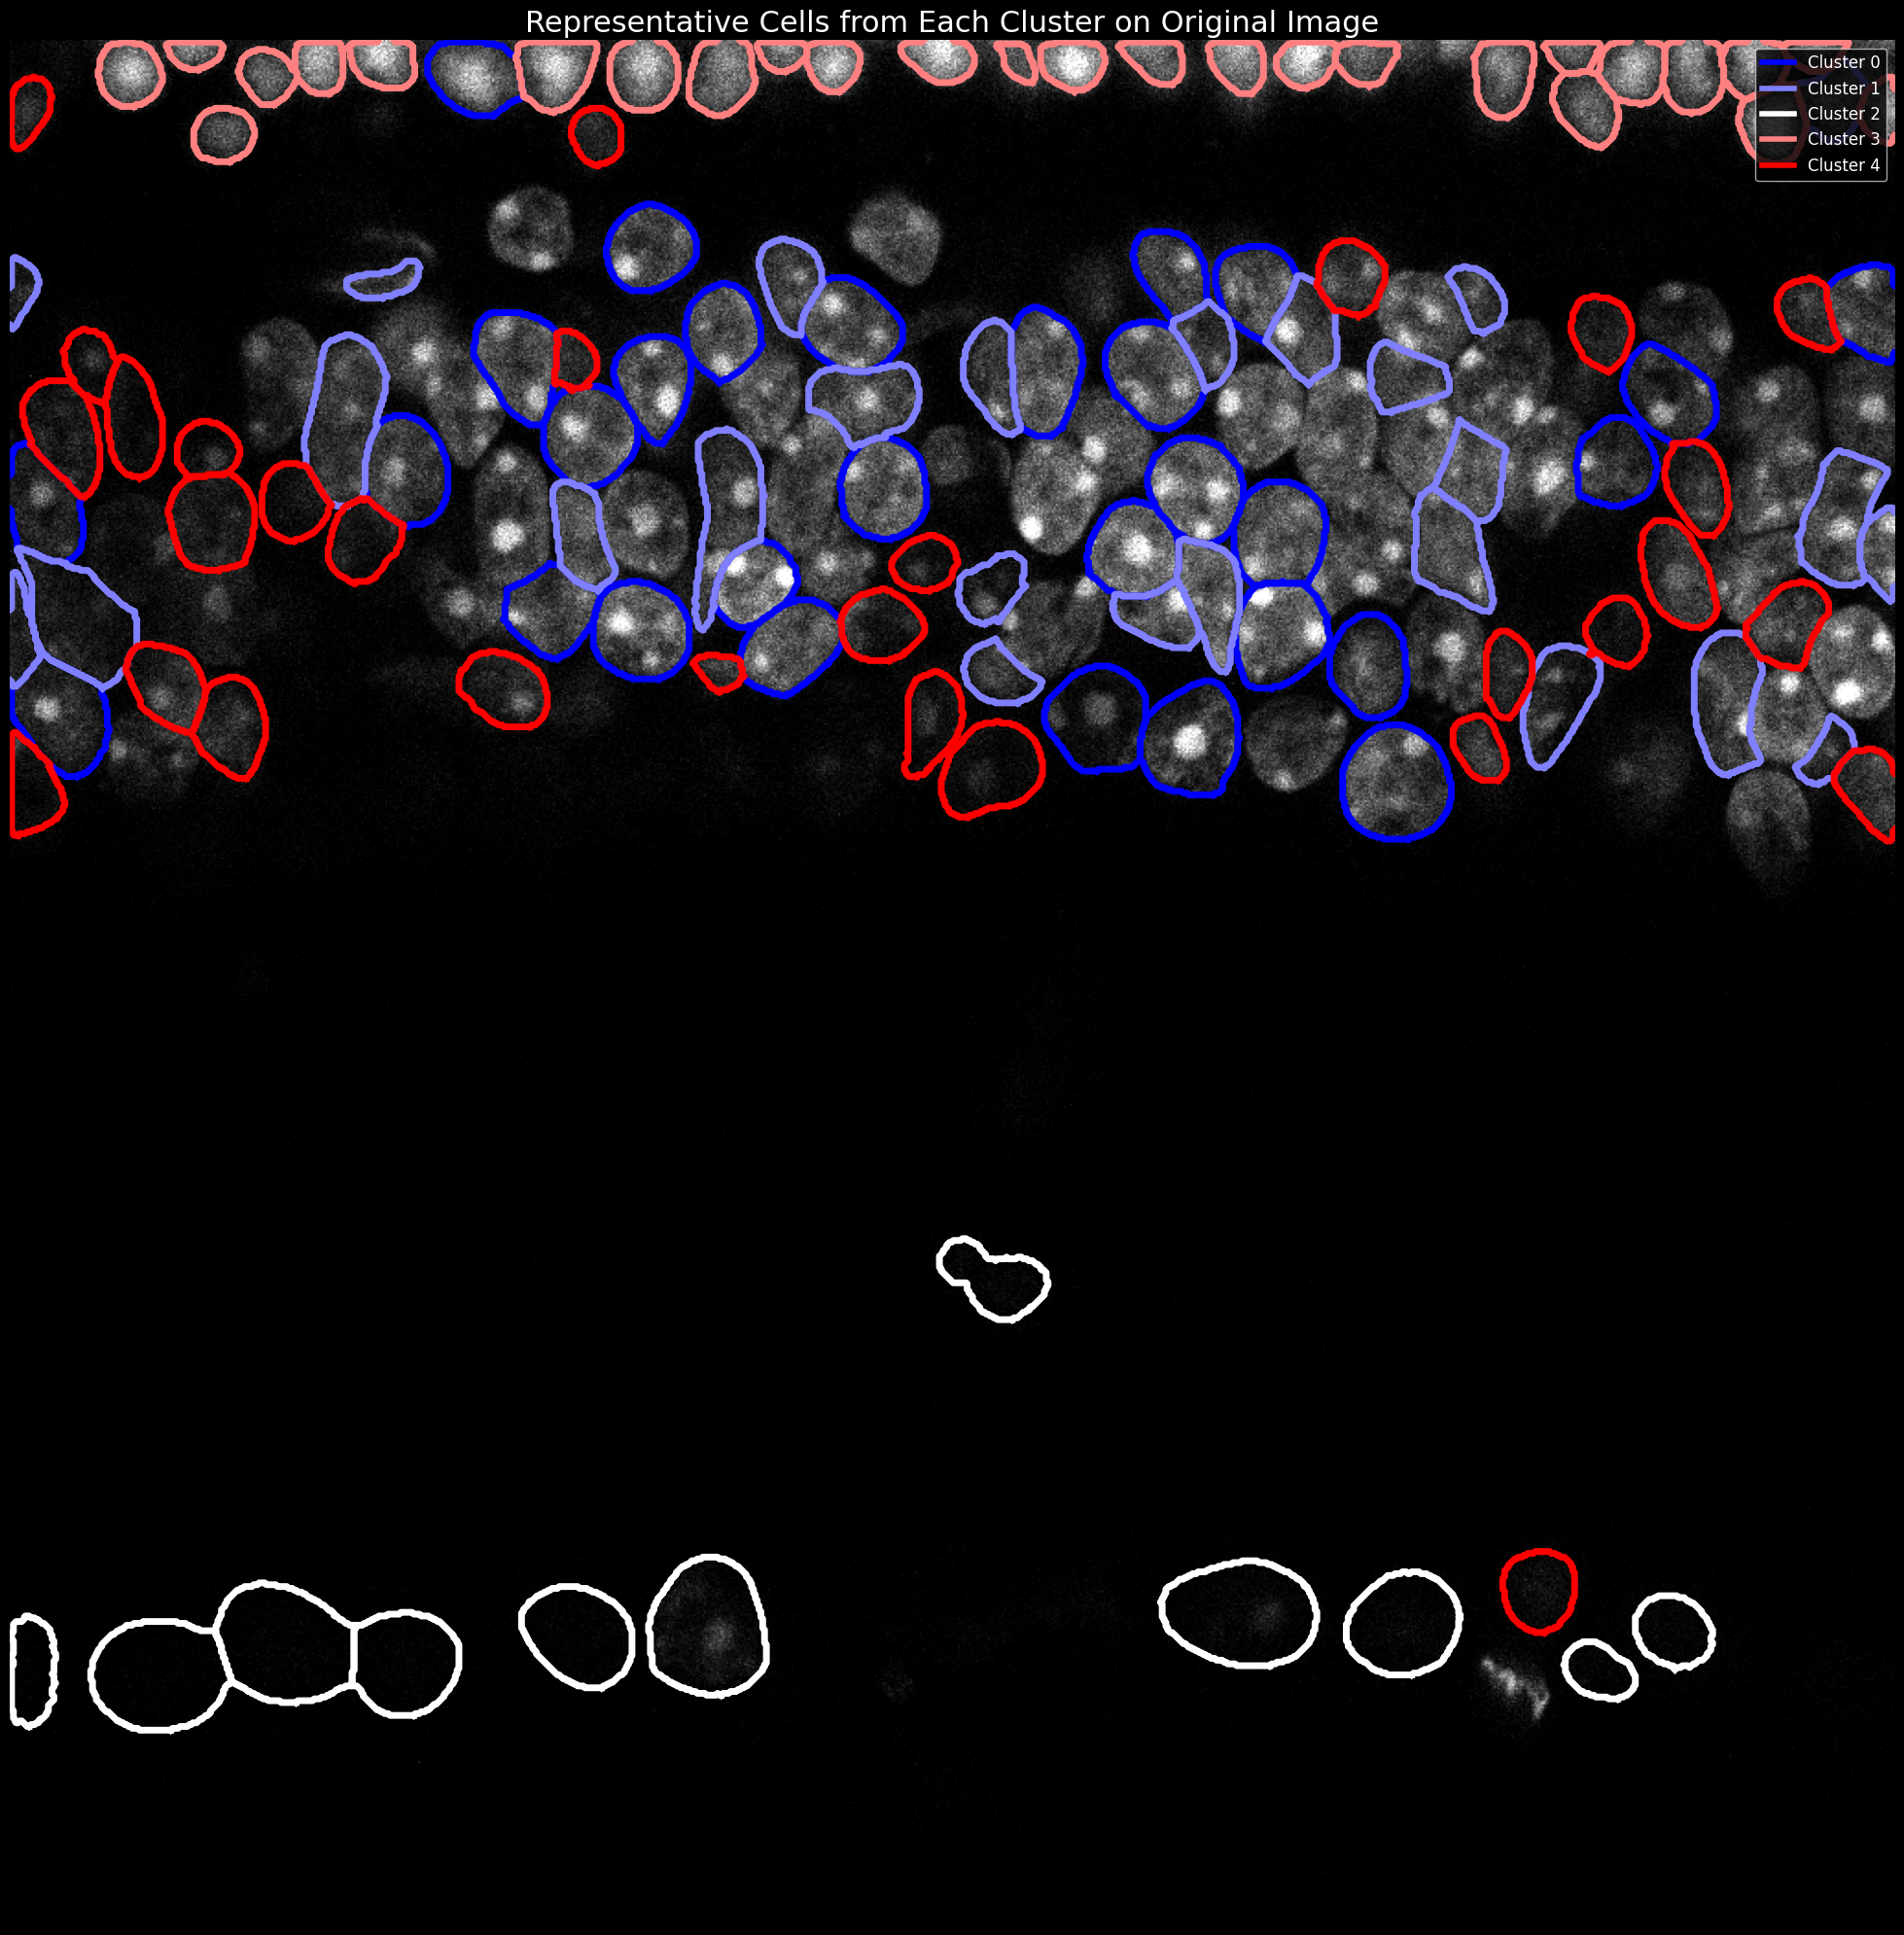

In [53]:
plot_representatives_on_image(features_df = df, segmentation_mask = labeled_mask, image= image)